# Importing packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
%matplotlib inline

# DATA ANALYSIS

In [2]:
# Read a comma-separated values (csv) file into pandas DataFrame
train = pd.read_csv(r'../input/titanic/train.csv')
test = pd.read_csv(r'../input/titanic/test.csv')
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [4]:
print(train.shape)
print(test.shape)

(891, 12)
(418, 11)


In [5]:
print(test.columns)
print(train.columns)

Index(['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')
Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')


In [6]:
#nullvalues in train dataset
train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [7]:
#nullvalues in test dataset
test.isnull().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [8]:
print(train["Sex"].value_counts())
print(train["Embarked"].value_counts())
print(train["SibSp"].value_counts())


male      577
female    314
Name: Sex, dtype: int64
S    644
C    168
Q     77
Name: Embarked, dtype: int64
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: SibSp, dtype: int64


<AxesSubplot:xlabel='Sex', ylabel='count'>

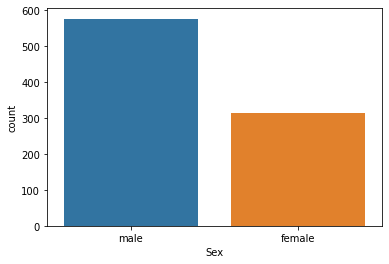

In [9]:
sns.countplot(x="Sex",data=train)

In [10]:
print(train["Ticket"].value_counts())

1601                 7
CA. 2343             7
347082               7
347088               6
3101295              6
                    ..
315037               1
349244               1
250651               1
349233               1
STON/O 2. 3101288    1
Name: Ticket, Length: 681, dtype: int64


# Cleaning The Dataset

In [11]:
title=set()
for name in train["Name"]:
    title.add(name.split(",")[1].split(".")[0].strip())
print(title)

{'Mrs', 'Master', 'Jonkheer', 'Rev', 'the Countess', 'Miss', 'Lady', 'Col', 'Capt', 'Sir', 'Mlle', 'Mme', 'Ms', 'Mr', 'Dr', 'Don', 'Major'}


In [12]:

titles={'Sir':"officer", 'Mme':"normlad", 'Mr':"norm", 'Master':"normlad", 'Don':"officer", 'Miss':"normlad", 'Lady':"normlad", 'Mlle':"normlad", 'Col':"officer", 'Ms':"normlad", 'the Countess':"royal", 'Mrs':"normlad", 'Major':"officer", 'Capt':"officer", 'Dr':"officer", 'Rev':"officer", 'Jonkheer':"royal"}

In [13]:
train["Name"]=train["Name"].map(lambda name:name.split(",")[1].split(".")[0].strip())
train["Name"]=train.Name.map(titles)
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,norm,male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,normlad,female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,normlad,female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,normlad,female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,norm,male,35.0,0,0,373450,8.0500,NaN,S


In [14]:
#Dropping Unwanted fields
df=train.drop(["Ticket","Cabin","PassengerId"],axis=1)
df.head()


,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,norm,male,22.0,1,0,7.2500,S
1,1,1,normlad,female,38.0,1,0,71.2833,C
2,1,3,normlad,female,26.0,0,0,7.9250,S
3,1,1,normlad,female,35.0,1,0,53.1000,S
4,0,3,norm,male,35.0,0,0,8.0500,S


In [15]:
#converting string values(Categorical Values) to integer
df.Sex=df.Sex.map({"female":0,"male":"1"})
df.Embarked=df.Embarked.map({"S":0,"C":"1","Q":2})
df.Name=df.Name.map({"royal":0,"normlad":1,"officer":2,"norm":3})
df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,3,1,22.0,1,0,7.2500,0
1,1,1,1,0,38.0,1,0,71.2833,1
2,1,3,1,0,26.0,0,0,7.9250,0
3,1,1,1,0,35.0,1,0,53.1000,0
4,0,3,3,1,35.0,0,0,8.0500,0


In [16]:
df.isnull().sum()

Survived      0
Pclass        0
Name          0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Embarked      2
dtype: int64

In [17]:
#Replacing all the null values

df.fillna(df.Age.mean(),inplace=True)
round(df["Age"],1)

df.head(10)

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,3,1,22.000000,1,0,7.2500,0
1,1,1,1,0,38.000000,1,0,71.2833,1
2,1,3,1,0,26.000000,0,0,7.9250,0
3,1,1,1,0,35.000000,1,0,53.1000,0
4,0,3,3,1,35.000000,0,0,8.0500,0
5,0,3,3,1,29.699118,0,0,8.4583,2
6,0,1,3,1,54.000000,0,0,51.8625,0
7,0,3,1,1,2.000000,3,1,21.0750,0
8,1,3,1,0,27.000000,0,2,11.1333,0
9,1,2,1,0,14.000000,1,0,30.0708,1


In [18]:
df.isnull().sum()

Survived    0
Pclass      0
Name        0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

In [19]:
df.describe()

,Survived,Pclass,Name,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,2.180696,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,0.976066,13.002015,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,1.000000,22.000000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,3.000000,29.699118,0.000000,0.000000,14.454200
75%,1.000000,3.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,3.000000,80.000000,8.000000,6.000000,512.329200


# Feature Scaling

In [20]:
# Standard ScalerThe Standard Scaler assumes data is normally distributed within each feature and scales them such
#that the distribution centered around 0, with a standard deviation of 1.
from sklearn.preprocessing import StandardScaler
df["Age"]=round((df.Age-df.Age.mean()/ df.Age.std()))
df["Fare"]=round((df.Fare-df.Fare.mean())/df.Fare.std())

In [21]:
df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,3,1,20.0,1,0,-1.0,0
1,1,1,1,0,36.0,1,0,1.0,1
2,1,3,1,0,24.0,0,0,-0.0,0
3,1,1,1,0,33.0,1,0,0.0,0
4,0,3,3,1,33.0,0,0,-0.0,0


In [22]:
df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,3,1,20.0,1,0,-1.0,0
1,1,1,1,0,36.0,1,0,1.0,1
2,1,3,1,0,24.0,0,0,-0.0,0
3,1,1,1,0,33.0,1,0,0.0,0
4,0,3,3,1,33.0,0,0,-0.0,0


# Data Modelling

In [23]:
from sklearn. model_selection import train_test_split

In [24]:
x_train,x_test,y_train,y_test=train_test_split(
    df.drop(["Survived"],axis=1),
    df.Survived,test_size=0.2,
    random_state=0,
    stratify=df.Survived)

# Logistic Regression

In [25]:
#Logistic Regression
from sklearn.linear_model import LogisticRegression

In [26]:
clf=LogisticRegression()
clf.fit(x_train,y_train)
from sklearn.metrics import accuracy_score
y_pred=clf.predict(x_test)
accuracy_score(y_test,y_pred)

0.8156424581005587

In [27]:
title=set()
for name in test["Name"]:
    title.add(name.split(",")[1].split(".")[0].strip())
print(title)

{'Mrs', 'Master', 'Rev', 'Miss', 'Col', 'Ms', 'Dona', 'Mr', 'Dr'}


In [28]:
titles={'Sir':"officer", 'Mme':"normlad", 'Mr':"norm", 'Master':"normlad", 'Don':"officer", 'Miss':"normlad", 'Lady':"normlad", 'Mlle':"normlad", 'Col':"officer", 'Ms':"normlad", 'the Countess':"royal", 'Mrs':"normlad", 'Major':"officer", 'Capt':"officer", 'Dr':"officer", 'Rev':"officer", 'Jonkheer':"royal"}

In [29]:
test["Name"]=test["Name"].map(lambda name:name.split(",")[1].split(".")[0].strip())
test["Name"]=test.Name.map(titles)
test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,norm,male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,normlad,female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,norm,male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,norm,male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,normlad,female,22.0,1,1,3101298,12.2875,NaN,S


In [30]:
#Dropping Unwanted fields
df1=test.drop(["Ticket","Cabin","PassengerId"],axis=1)
df1.head()


,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,norm,male,34.5,0,0,7.8292,Q
1,3,normlad,female,47.0,1,0,7.0000,S
2,2,norm,male,62.0,0,0,9.6875,Q
3,3,norm,male,27.0,0,0,8.6625,S
4,3,normlad,female,22.0,1,1,12.2875,S


In [31]:
#converting string values(Categorical Values) to integer
df1.Sex=df1.Sex.map({"female":0,"male":"1"})
df1.Embarked=df1.Embarked.map({"S":0,"C":"1","Q":2})
df1.Name=df1.Name.map({"royal":0,"normlad":1,"officer":2,"norm":3})
df1.head()

,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,3.0,1,34.5,0,0,7.8292,2
1,3,1.0,0,47.0,1,0,7.0000,0
2,2,3.0,1,62.0,0,0,9.6875,2
3,3,3.0,1,27.0,0,0,8.6625,0
4,3,1.0,0,22.0,1,1,12.2875,0


In [32]:
df1.isnull().sum()

Pclass       0
Name         1
Sex          0
Age         86
SibSp        0
Parch        0
Fare         1
Embarked     0
dtype: int64

In [33]:
#Replacing all the null values

df1.fillna(df1.Age.mean(),inplace=True)

In [34]:
df1.isnull().sum()

Pclass      0
Name        0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

In [35]:
df1["Age"]=round((df1.Age-df1.Age.mean()/ df1.Age.std()))
df1["Fare"]=round((df1.Fare-df1.Fare.mean())/df1.Fare.std())


In [36]:
df1.head()

,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,3.0,1,32.0,0,0,-0.0,2
1,3,1.0,0,45.0,1,0,-1.0,0
2,2,3.0,1,60.0,0,0,-0.0,2
3,3,3.0,1,25.0,0,0,-0.0,0
4,3,1.0,0,20.0,1,1,-0.0,0


In [37]:
pred=clf.predict(df1)

In [38]:
pred

array([0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1,
       1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1,
       1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1,
       1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1,
       0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1,
       0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0,